# 1. Introduction

In many real-world problems, the quantities we care about are not observed directly. Instead, we only have access to indirect and noisy measurements. Bayesian inference provides a principled way to reason about such uncertainty and to learn about hidden quantities from observed data.

In this tutorial, we build an intuition for **Bayesian posterior inference** and use **BayesFlow** as a practical tool for solving such problems. We begin with the core ideas and a motivating example, and then move on to how BayesFlow can learn posterior inference from simulations.

## A motivating example: rabbits on an island

Throughout this tutorial, we use a simple but meaningful ecological example: a rabbit population living on an island. We assume that the hidden population evolves according to a **logistic growth process**.

The process of interest is hidden, while the data we observe are only imperfect measurements of it. In ecology, researchers may record animal counts over time, but these counts do not fully reveal the true population dynamics. Some animals may be missed, some may move, and measurements are never perfectly accurate.

What scientists often care about are not only the observations themselves, but also the **hidden mechanisms** that generate them. For example, they may want to understand:

- how quickly the population grows,
- whether the population is approaching a natural limit,
- and what future population behavior is likely.

This is exactly the kind of problem BayesFlow is designed for.

## The unknown parameters

In our rabbit population model, the two main unknown ecological parameters are:

- the **growth rate** $r$
- the **carrying capacity** $K$

We do not observe these parameters directly. Instead, we observe noisy population counts over time. Our goal is to infer which values of $r$ and $K$ are plausible given the observed data.

This is a **Bayesian inference problem**.

## Why this is a Bayesian problem

In Bayesian inference, we do not seek a single “best” value for each parameter. Instead, we aim to characterize the **posterior distribution**: the range of parameter values that are plausible after taking the observed data into account.

This is especially useful in settings where uncertainty matters. Rather than making overly confident conclusions, Bayesian inference allows us to quantify what we know, what we do not know, and how strongly the data support different explanations.

## Goals of this tutorial

This tutorial has two main goals:

1. to teach the basic ideas behind Bayesian posterior inference,
2. to show how BayesFlow can learn to perform this inference efficiently from simulated data.



## 2. What is posterior inference?

Suppose we use $x$ to denote the observed data and $\theta$ to denote the unknown parameters.

In Bayesian inference, the central object is the **posterior distribution**

$$
p(\theta \mid x),
$$

which answers the question:

> After observing the data, which parameter values are plausible?

This is different from ordinary point estimation. Instead of returning a single best value, Bayesian inference returns a **full distribution** over possible parameter values. This allows us to reason explicitly about uncertainty.

![Forward and inverse view of inference](img/posterior.png)

*Forward direction: parameters generate data. Inverse direction: observed data are used to infer plausible parameters.*

### Forward problem vs. inverse problem

It is useful to distinguish between two directions of reasoning:

#### The forward problem

In the **forward problem**, we start with parameters $\theta$ and ask what kind of data $x$ they would generate. This is described by the likelihood

$$
p(x \mid \theta).
$$

In our rabbit population example, this means:

- choose parameters such as the growth rate $r$, the carrying capacity $K$, and the observation noise standard deviation $\sigma_{\mathrm{obs}}$,
- simulate the hidden population dynamics,
- and then generate noisy observed counts from that process.

So the forward direction goes from **parameters to data**.

#### The inverse problem

In the **inverse problem**, we go in the opposite direction. We start with the observed data $x$ and ask:

> Which parameter values $\theta$ could have plausibly produced these observations?

This is harder than the forward problem, because the same observed data can often be explained by many different parameter values, especially when the data are noisy.

Bayesian posterior inference solves this inverse problem by returning a distribution over plausible parameters:

$$
p(\theta \mid x).
$$

So the inverse direction goes from **data back to parameters**.

### Bayes' rule

The posterior is defined through **Bayes' rule**:

$$
p(\theta \mid x) = \frac{p(x \mid \theta)\, p(\theta)}{p(x)}.
$$

Each part has a specific meaning:

**The prior: $p(\theta)$** represents which parameter values we consider plausible *before* seeing the data.

**The likelihood: $p(x \mid \theta)$** describes how well a parameter setting $\theta$ explains the observed data $x$.

**The posterior: $p(\theta \mid x)$** combines prior knowledge with the evidence from the data. It represents our updated belief about the parameters after observing $x$.

**The evidence: $p(x)$** is a normalizing constant that ensures the posterior distribution integrates to one.

### The key intuition

For intuition, the most important relationship is:

$$
\text{posterior} \propto \text{likelihood} \times \text{prior}.
$$

This means that a parameter value becomes plausible in the posterior if:

1. it was already plausible under the prior,  
2. and it explains the observed data well.

### 3. Posterior inference in our ecology example

In our rabbit population model, the unknown parameters are

$$
\theta = (r, K),
$$

where:

- $r$ is the population growth rate,
- $K$ is the carrying capacity.

The observed data $x$ are the noisy animal counts recorded over time. Our goal is therefore to infer the posterior distribution

$$
p(r, K \mid \text{observed counts}).
$$

This posterior tells us which combinations of growth rate and carrying capacity are most consistent with the data, and how uncertain we are about them.

### Why this matters

Unlike ordinary machine learning, where we often want a single prediction, Bayesian inference gives us a **distribution of plausible parameter values**. This is especially important in scientific problems, where uncertainty is often just as important as the estimate itself.

A posterior distribution allows us to:

- quantify uncertainty,
- compare competing explanations,
- and make future predictions in a principled, uncertainty-aware way.

## 4. Why not just use ordinary machine learning?

This is one of the most important ideas to understand before using BayesFlow.

In ordinary supervised machine learning, we usually train on many real examples of the form:

$$
(\text{input}, \text{label})
$$

For example:

- house features $\rightarrow$ house price
- image $\rightarrow$ object label

The model learns a mapping from inputs to known outputs.

In our ecology problem, however, the hidden parameters are **not labeled** in the real data. We may observe a rabbit-count trajectory such as

$$
10.6, 11.8, 15.3, 17.1, 22.2, 25.2, 31.1, 34.6, 41.8, 46.8, \dots
$$

which is the beginning of your observed 40-point trajectory.

But we still do not know the true growth rate $r$ or carrying capacity $K$ that generated it.

That is exactly the inference problem we want to solve.

So, unlike in standard supervised learning, we do **not** have a real dataset of the form

$$
\text{trajectory} \rightarrow (r, K).
$$

Without such labels, ordinary supervised learning cannot be applied directly.

This is where BayesFlow takes a different approach: if real labels are unavailable, we generate **synthetic labeled data** using a simulator.

In other words, BayesFlow creates training examples in which the hidden parameters are known because we generated them ourselves. This is the key idea that makes simulation-based Bayesian inference possible.


## 5. The BayesFlow idea

BayesFlow is useful when we can describe **how data are generated**, even if direct inference is difficult.

In our example, the idea is simple:

- choose hidden ecological parameters,
- simulate a rabbit population trajectory,
- add noise to mimic imperfect observations,
- use the simulated observations as input,
- and use the generating parameters as the target.

This gives us synthetic training pairs of the form:

$$
\text{simulated trajectory} \rightarrow \text{true generating parameters}.
$$

In this way, the inference problem becomes a supervised learning problem on simulated data.

BayesFlow then learns the reverse task:

> given an observed trajectory, infer which hidden parameters likely generated it.

After training, the network can perform posterior inference quickly on new datasets from the same model family.

This is why BayesFlow is called an **amortized inference** method: training may be expensive, but inference on new similar datasets is fast.


## 6. The ecological model in intuitive terms

Let us now describe the ecological story in a more intuitive way.

Imagine a rabbit population living on an island.

At first, when the population is small, rabbits reproduce quickly because food and space are plentiful. As the population grows, resources become more limited, so growth begins to slow down. Over time, the population approaches a natural environmental limit, called the **carrying capacity**.

If we could observe the system perfectly, we would see a smooth population trajectory determined by hidden ecological parameters such as the growth rate and the carrying capacity.

In reality, however, we do not observe this process directly. Instead, ecologists collect **noisy counts**:

- some rabbits are missed,
- visibility changes over time,
- and measurements are never perfectly accurate.

This means the problem has two layers:

### Hidden process

The true rabbit population changes over time according to ecological dynamics.

### Observation process

We only observe noisy measurements of that hidden population.

Our **data** come from the observation process, but our **scientific interest** lies in the hidden process.

That gap is exactly why inference is needed.

## 7. Logistic growth with noisy observations

To keep this tutorial simple, we assume that the hidden rabbit population follows a **logistic growth model**.

Let $N_t$ denote the true population size at time $t$. We model its evolution in discrete time by

$$
N_{t+1} = N_t + r N_t \left(1 - \frac{N_t}{K}\right),
$$

where:

- $r$ is the **growth rate**,
- $K$ is the **carrying capacity**.

This equation has a simple interpretation.

The term $N_t$ is the current population size. The growth term $rN_t$ says that, without constraints, a larger population tends to produce more offspring. The factor

$$
\left(1 - \frac{N_t}{K}\right)
$$

introduces environmental limits. When the population is small relative to $K$, this term is close to 1, so growth is strong. As the population approaches $K$, the term becomes smaller, so growth slows down. When $N_t = K$, growth stops.

As a result, the logistic model produces the familiar **S-shaped trajectory**:

- slow growth at the beginning,
- faster growth in the middle,
- and flattening as the population approaches its limit.

This is a simple but useful model for population dynamics.

### Adding an observation model

The logistic equation describes the **hidden true population**, but ecologists do not observe this process perfectly. Instead, they observe noisy counts. We therefore add an observation model:

$$
y_t = N_t + \varepsilon_t,
$$

where

$$
\varepsilon_t \sim \mathcal{N}(0, \sigma_{\text{obs}}^2).
$$

This means that the observed count $y_t$ is the true population $N_t$ plus random observation noise.

The model therefore has two levels:

- **Latent state:** $N_1, N_2, \dots, N_T$
- **Observed data:** $y_1, y_2, \dots, y_T$

In words:

- the true population evolves according to logistic growth,
- and we observe noisy versions of that hidden process.

This observation layer makes the model more realistic and explains why uncertainty is unavoidable: the data are only an imperfect view of the underlying ecological dynamics.

## 8. What are we trying to infer?

Now that the model is fully specified, the inference target can be stated precisely.

We observe a sequence of noisy population counts,

$$
y_{1:T},
$$

and we want to infer the unknown ecological parameters

$$
r, K.
$$

Our goal is therefore to estimate the posterior distribution

$$
p(r, K \mid y_{1:T}).
$$

This posterior tells us:

- which values of the growth rate $r$ are plausible,
- which values of the carrying capacity $K$ are plausible,
- how uncertain we are about both parameters,
- and whether different parameter combinations explain the data equally well.

This posterior distribution is the main scientific output of the tutorial.

The goal is **not** to obtain neural-network weights, and it is **not** to produce a single predicted number. Instead, the goal is to recover a probability distribution over meaningful ecological parameters.

## 9. Priors and simulation-based training

Before observing any rabbit counts, we need to specify which parameter values are plausible. This is the role of the **prior**.

In our model, the hidden parameters are

$$
\theta = (r, K),
$$

where:

- $r$ is the growth rate,
- $K$ is the carrying capacity.

To keep the tutorial simple, we choose broad uniform priors:

$$
r \sim \mathrm{Uniform}(0.08, 0.40)
$$

$$
K \sim \mathrm{Uniform}(90, 130)
$$

These priors mean that, before seeing the data, we consider growth rates between 0.05 and 0.60 and carrying capacities between 50 and 200 rabbits to be plausible.

These are not special values; they simply define a reasonable range for this tutorial. In a more realistic application, priors could be informed by expert knowledge, previous studies, or biological constraints. Here, uniform priors are useful because they are easy to interpret.

### Why priors matter

Bayesian inference always starts with a prior belief about plausible parameter values. The observed data then update that belief to produce the posterior. Without a prior, there is no Bayesian posterior inference.

### How simulation creates training data

This is the key idea behind BayesFlow.

For real rabbit data, we do not know the true values of $r$ and $K$—that is exactly what we want to infer. So instead of relying on labeled real data, we generate labeled data ourselves through simulation.

Each simulated training example is created in three steps:

1. **Sample parameters from the prior**

   Draw a random parameter pair

   $$
   (r, K) \sim p(r, K).
   $$

2. **Simulate the hidden population**

   Using the logistic growth equation,

   $$
   N_{t+1} = N_t + r N_t \left(1 - \frac{N_t}{K}\right),
   $$

   generate a hidden population trajectory

   $$
   N_1, N_2, \dots, N_T.
   $$

3. **Add observation noise**

   Convert the hidden trajectory into noisy observations:

   $$
   y_t = N_t + \varepsilon_t,
   \qquad
   \varepsilon_t \sim \mathcal{N}(0, \sigma_{\text{obs}}^2).
   $$

   This produces an observed trajectory

   $$
   y_1, y_2, \dots, y_T.
   $$

At the end, one simulated training example looks like this:

- **input:** noisy rabbit counts over time
- **target:** the true parameters $(r, K)$ that generated them

This is the central trick of BayesFlow: **simulation turns an unlabeled inference problem into a supervised learning problem**.

For real data, the hidden parameters are unknown. For simulated data, we know exactly which parameters generated the observations. That is what allows BayesFlow to learn posterior inference.

## 10. The observed rabbit dataset

We now define the single observed dataset that we want to analyze after training.

For this tutorial, we use a synthetic but realistic **40-point observed trajectory**:

$$
10.6, 11.8, 15.3, 17.1, \dots, 107.8, 108.0
$$

This trajectory still shows the characteristic shape of logistic growth:

- the observations increase rapidly at first,
- the growth then begins to slow,
- and the series eventually levels off near a carrying capacity.

Because we add Gaussian observation noise in the model, the observed values do not have to be whole numbers. So values such as `10.6` or `107.8` are completely consistent with this tutorial setup. You can think of them as noisy field measurements of an underlying population process.

This observed trajectory is **not** the training set.
It is the single dataset we want to analyze **after** BayesFlow has been trained on many simulated trajectories generated from the model.


## 11. Implementing the model in BayesFlow

### Imports and setup

We begin by importing the libraries we need. BayesFlow v2 uses Keras 3 as a backend, so the backend should be set before importing BayesFlow.

In [1]:
import os
if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import matplotlib.pyplot as plt
import bayesflow as bf

INFO:numexpr.utils:NumExpr defaulting to 8 threads.
INFO:bayesflow:Using backend 'tensorflow'
C:\Users\BCC\anaconda3\envs\torch_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Observed data representation

Our observed rabbit counts are the dataset we ultimately want to analyze. In the code, we store them as a time series and append the time index as a second feature. This gives BayesFlow a structured sequential input.

In [2]:
observed_counts = np.array([
    10.6, 11.8, 15.3, 17.1, 22.2, 25.2, 31.1, 34.6, 41.8, 46.8,
    54.6, 59.5, 66.9, 71.7, 78.9, 83.1, 88.6, 91.3, 96.0, 97.4,
    100.5, 101.6, 103.8, 104.0, 105.5, 105.6, 106.7, 106.6, 107.2, 107.1,
    107.5, 107.5, 107.8, 107.7, 107.9, 107.8, 107.9, 108.0, 107.8, 108.0
], dtype=np.float32).reshape(-1, 1)

T = len(observed_counts)
time_points = np.arange(T, dtype=np.float32).reshape(-1, 1)

observed_series = np.concatenate([observed_counts, time_points], axis=-1)

print("observed_series shape:", observed_series.shape)
print("first 5 rows:")
print(observed_series[:5])
print("last 5 rows:")
print(observed_series[-5:])

observed_series shape: (40, 2)
first 5 rows:
[[10.6  0. ]
 [11.8  1. ]
 [15.3  2. ]
 [17.1  3. ]
 [22.2  4. ]]
last 5 rows:
[[107.8  35. ]
 [107.9  36. ]
 [108.   37. ]
 [107.8  38. ]
 [108.   39. ]]


### Visualizing the observed trajectory

Before doing any modeling, it is always a good idea to inspect the observed data.

Here we now have a **40-time-point trajectory** \. Visually, it should look like a noisy logistic curve: fast growth at the beginning, then a gradual flattening as the population approaches its carrying capacity.


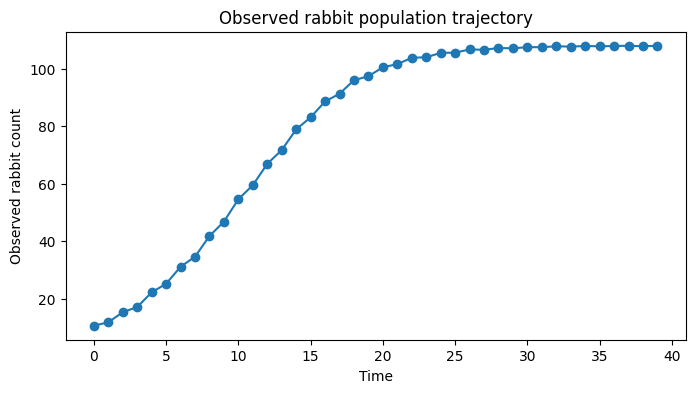

In [3]:
plt.figure(figsize=(8, 4))
plt.plot(time_points, observed_counts, marker="o")
plt.xlabel("Time")
plt.ylabel("Observed rabbit count")
plt.title("Observed rabbit population trajectory")
plt.show()

This curve should show the typical logistic pattern:

- rapid growth at first,
- slower growth later,
- flattening near a limit

### Fixed model settings

Next, we define a few constants that are used throughout the simulator.

In this tutorial, the initial population $N_0$ and the time step $\Delta t$ are treated as known and fixed. 

In [4]:
rng = np.random.default_rng(123)

N0 = 10.6          # fixed initial population
dt = 1.0           # time step
sigma_obs = 2  # fixed observation noise

For this notebook, we infer three unknown parameters:

- the growth rate $r$,
- the carrying capacity $K$,
- the observation noise standard deviation $\sigma_{\mathrm{obs}}$.

This keeps the example realistic enough to model noisy ecological observations.

### Prior specification

The first component of the BayesFlow simulator is the **prior function**. Its role is to sample plausible values for the hidden parameters $r$ and $K$.

In our tutorial, this corresponds to the priors

$$
r \sim \mathrm{Uniform}(0.08, 0.40), \qquad K \sim \mathrm{Uniform}(90, 130).
$$

Each call to the prior function draws one parameter pair from these distributions.

The output is returned as a **dictionary**, because BayesFlow expects parameters to be provided as named variables. Here, the hidden parameters are stored under the keys `"r"` and `"K"`.



In [5]:
def prior():
    r = rng.uniform(0.08, 0.40, size=(1,)).astype(np.float32)
    K = rng.uniform(90.0, 130.0, size=(1,)).astype(np.float32)
    return {"r": r, "K": K}

### Latent population simulator

The next component of the simulator is the **latent ecological process**. Given the parameters $r$ and $K$, we generate the hidden population trajectory using the discrete logistic growth equation.

In [6]:
def logistic_trajectory(r, K, T=T, N0=N0, dt=dt):
    N = np.zeros((T, 1), dtype=np.float32)
    current = float(N0)

    for t in range(T):
        N[t, 0] = current
        current = current + dt * float(r) * current * (1.0 - current / float(K))
        current = max(current, 1e-3)

    return N

This corresponds to the logistic growth update

$$
N_{t+1} = N_t + r N_t \left(1 - \frac{N_t}{K}\right).
$$

The returned array `N` represents the **hidden latent population trajectory**. It is the true ecological process before any observation noise is added.

Later, we convert this latent trajectory into the actually observed series by adding Gaussian noise and attaching the time index. In this notebook, that observed series has shape `(T, 2)`, where the first column contains the noisy counts and the second column contains the time points.

In this logistic-growth example, the likelihood could still be written down explicitly because the observation model is simple. We nevertheless implement the model as a simulator, since this is the more general BayesFlow perspective. BayesFlow is especially useful in settings where we can generate data from a model but cannot easily write or evaluate the likelihood itself.


### Observation model

In reality, ecologists do not observe the latent population directly. They observe noisy counts. This section of the simulator takes the latent trajectory and adds Gaussian noise to produce realistic observations.

In [7]:
def likelihood(r, K):
    latent_N = logistic_trajectory(r[0], K[0])

    noisy_counts = latent_N + rng.normal(
        loc=0.0,
        scale=sigma_obs,
        size=latent_N.shape
    ).astype(np.float32)

    noisy_counts = np.clip(noisy_counts, 0.0, None)

    series = np.concatenate([noisy_counts, time_points], axis=-1).astype(np.float32)

    return {"series": series}

This implements the observation model

$$
y_t = N_t + \varepsilon_t,
\qquad
\varepsilon_t \sim \mathcal{N}(0, \sigma_{\text{obs}}^2).
$$

The output is stored under the key `"series"`, which represents the observed variable that BayesFlow will condition on during inference.

### BayesFlow simulator

We now combine the prior and the observation model into a single BayesFlow simulator.

In [8]:
simulator = bf.make_simulator([prior, likelihood])

### Inspecting simulated training data

Before training, it is useful to inspect a few simulated examples. This helps us verify that the simulator produces trajectories that look sensible.

In [9]:
batch = simulator.sample(4)
print({k: v.shape for k, v in batch.items()})

{'r': (4, 1), 'K': (4, 1), 'series': (4, 40, 2)}


This means:

- 4 simulated datasets were generated,
- each dataset contains one sampled value of $r$,
- one sampled value of $K$,
- one sampled value of $\sigma_{\mathrm{obs}}$,
- and one simulated trajectory of shape $(40, 2)$.

The shape $(40, 2)$ comes from:

- 40 time points,
- 1 column for the noisy observed counts,
- 1 column for the corresponding time index.

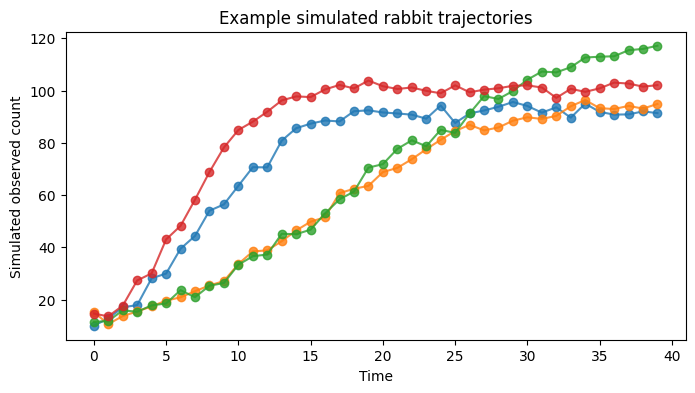

In [10]:
plt.figure(figsize=(8, 4))
for i in range(4):
    plt.plot(batch["series"][i, :, 1], batch["series"][i, :, 0], marker="o", alpha=0.8)

plt.xlabel("Time")
plt.ylabel("Simulated observed count")
plt.title("Example simulated rabbit trajectories")
plt.show()

This visual check is important. If the simulator produces trajectories that look completely unrealistic, then BayesFlow will learn inference for the wrong kind of data.

### Summary network

Our observed data are sequential, so we use a summary network designed for time series. Its role is to read the full trajectory and compress it into a learned representation that is useful for inference.

In [11]:
summary_net = bf.networks.TimeSeriesTransformer(
    summary_dim=32,
    time_axis=-1
)

That maps the whole observed trajectory to a fixed-size summary vector.

This is similar to feature extraction in ordinary machine learning, except that the features are learned automatically from simulated data.

### BayesFlow workflow

Next, we connect the simulator and the summary network inside a `BasicWorkflow`. This tells BayesFlow which variables are hidden parameters and which variable is the observed data.


In [12]:
workflow = bf.BasicWorkflow(
    simulator=simulator,
    summary_network=summary_net,
    inference_variables=["r", "K"],
    summary_variables="series",
    standardize="all",
    initial_learning_rate=1e-3,
)

This means:

- infer the posterior over `"r"` and `"K"`,
- condition on the observed time series `"series"`.

This workflow is the central BayesFlow object that we will train and later use for inference.

### Training the workflow

Training is the expensive **amortization** step. During this phase, BayesFlow repeatedly simulates artificial ecological worlds and learns how to map observed trajectories back to plausible values of $r$ and $K$.

One practical note: the training loss in BayesFlow can become **negative**, and that is not automatically a problem. What matters more is whether training stabilizes and whether the downstream diagnostics on simulated validation data are acceptable.

In [13]:
validation_data = simulator.sample(1000)

history = workflow.fit_online(
    epochs=100,
    num_batches_per_epoch=100,
    batch_size=64,
    validation_data=validation_data,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 36s 108ms/step - loss: 1.5724 - val_loss: -0.7465
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - loss: -1.0266 - val_loss: -1.9399
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: -1.2034 - val_loss: -1.5682
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: -1.3982 - val_loss: -2.0060
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: -1.2702 - val_loss: -1.6454
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - loss: -1.4709 - val_loss: -2.3777
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: -1.8576 - val_loss: -2.2382
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: -1.6974 - val_loss: -1.9936
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - loss: -1.9362 - val_loss: -2.5238
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: -2.1549 - val_loss: -2.4630
Epoch 11/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - loss: -2.2008 - val_loss: -2.2646
Epoc

INFO:bayesflow:Training completed in 16.07 minutes.


### Diagnostics

After training, we should not immediately trust the learned posterior. A good practice is to first evaluate the model on **simulated validation data**, where the true parameter values are known. This lets us check whether BayesFlow has learned to approximate the posterior well enough before applying it to the observed rabbit trajectory.

In this section, we will use several diagnostics, each addressing a different question:

- Does the posterior look reasonable for a single dataset?
- Can the model recover the true parameters across many datasets?
- Are the posterior intervals well calibrated?
- Does the posterior actually learn from the data?

We begin by generating validation datasets and drawing posterior samples from them.

In [19]:
# Validation data
num_val = 10000
num_samples = 200

val_sims = simulator.sample(num_val)

post_draws = workflow.sample(
    conditions={"series": val_sims["series"]},
    num_samples=num_samples,
    split=False
)

print("val_sims['r']:", val_sims["r"].shape)
print("val_sims['K']:", val_sims["K"].shape)

print("post_draws['r']:", post_draws["r"].shape)
print("post_draws['K']:", post_draws["K"].shape)

Sampling: 100%|███████████████████████████████████████████████████████████████████████| 1/1 [00:32<00:00, 32.50s/batch]
INFO:bayesflow:Sampling completed in 32.53 seconds.


val_sims['r']: (10000, 1)
val_sims['K']: (10000, 1)
post_draws['r']: (10000, 200, 1)
post_draws['K']: (10000, 200, 1)


Here:

- `val_sims` contains simulated trajectories together with the true parameter values used to generate them, namely $r$, $K$, and $\sigma_{\mathrm{obs}}$,
- `post_draws` contains posterior samples for these same parameters, produced by the trained BayesFlow workflow.

This gives us the basic setup for all the diagnostics that follow.

In [20]:
r_target = val_sims["r"]
K_target = val_sims["K"]


r_draws = post_draws["r"]
K_draws = post_draws["K"]


targets_arr = np.concatenate([r_target, K_target], axis=-1)
estimates_arr = np.concatenate([r_draws, K_draws], axis=-1)

print("targets_arr:", targets_arr.shape)
print("estimates_arr:", estimates_arr.shape)

targets_arr: (10000, 2)
estimates_arr: (10000, 200, 2)


#### Inspecting the posterior of one validation dataset

A useful first check is to look at the posterior for one simulated dataset where we know the ground truth.
If the model has learned well, the true values should lie in a plausible region of the posterior.

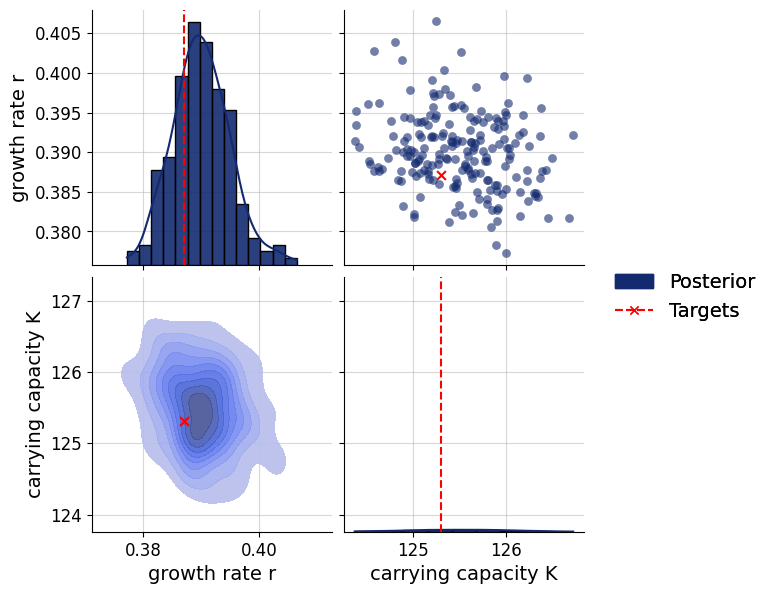

In [21]:
bf.diagnostics.plots.pairs_posterior(
    estimates=post_draws,
    targets=val_sims,
    dataset_id=0,
    variable_names=["growth rate r", "carrying capacity K"],
)

### Recovery: can the model recover the true parameters?

Next, we check recovery across many simulated datasets.

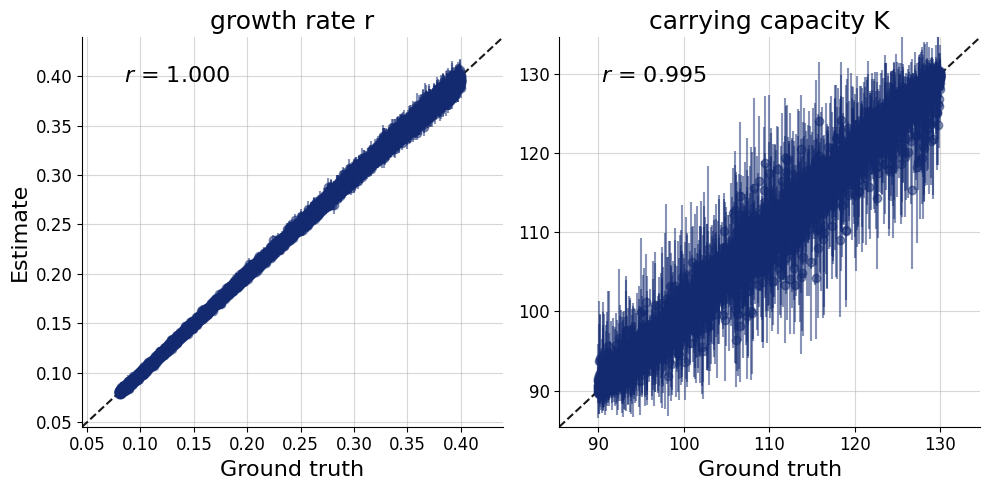

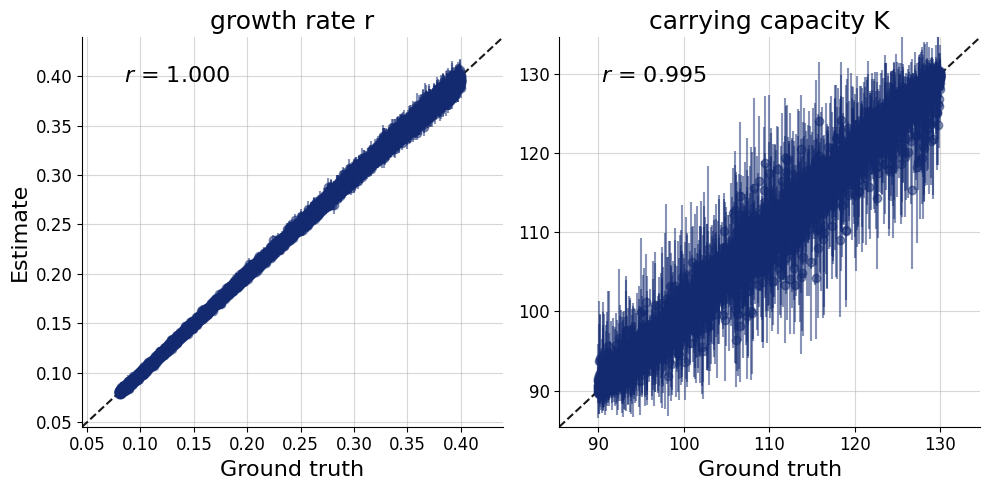

In [22]:
bf.diagnostics.plots.recovery(
    estimates=post_draws,
    targets=val_sims,
    variable_names=["growth rate r", "carrying capacity K"],
)

### Calibration histogram

Good recovery alone is not enough. A model may recover parameters reasonably well on average but still produce posteriors that are too narrow or too wide.

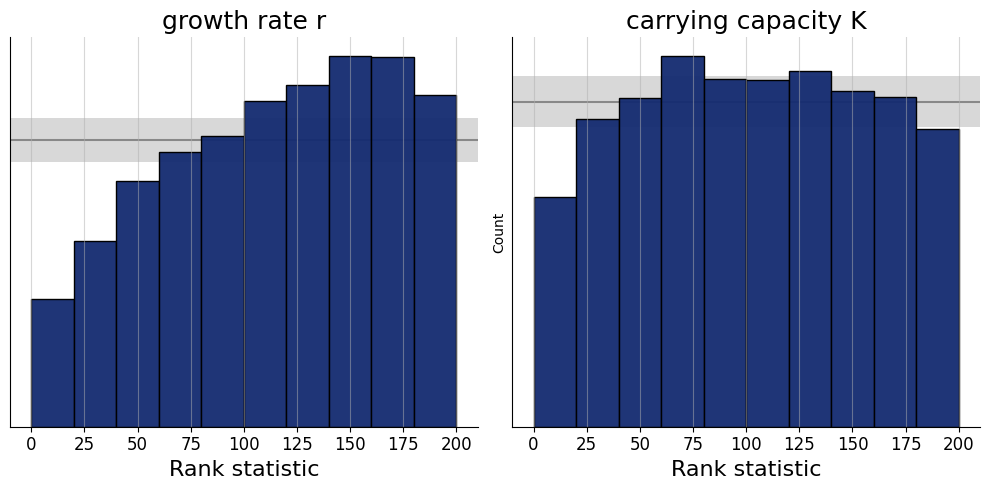

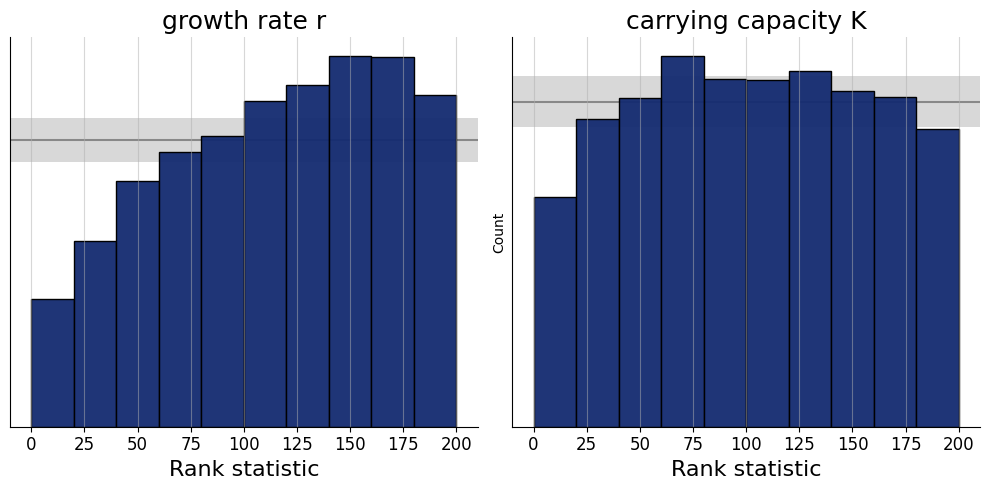

In [23]:
bf.diagnostics.plots.calibration_histogram(
    estimates=post_draws,
    targets=val_sims,
    variable_names=["growth rate r", "carrying capacity K"],
)

A roughly uniform histogram is desirable. A U-shape suggests overconfidence, a hump in the middle suggests underconfidence, and strong skewness suggests bias. This diagnostic checks whether the posterior uncertainty is calibrated.
